# Chapter 12.7: Emerging Modalities for Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand recommendation challenges in AR/VR and spatial computing
2. Design recommendation systems for IoT and smart home environments
3. Build voice-first recommendation interfaces for conversational agents
4. Implement cross-modal recommendation (text query to multimodal results)
5. Model spatial and temporal context for embodied recommendation
6. Handle multimodal feature fusion for recommendation
7. Evaluate recommendations across different interaction modalities

## Prerequisites

- Understanding of neural recommendation models (Parts 5-6)
- Familiarity with embedding spaces and similarity search
- Basic knowledge of multimodal learning
- PyTorch proficiency

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part12/chapter_12.7_emerging_modalities.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part12/chapter_12.7_emerging_modalities.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cpu')

print("All imports successful!")

All imports successful!


## 1. The Multimodal Recommendation Landscape

Traditional recommendation focuses on screen-based interaction. Emerging modalities include:

| Modality | Input | Output | Context |
|----------|-------|--------|----------|
| AR/VR | Gaze, gesture, spatial | 3D objects, overlays | Physical space |
| IoT | Sensor data, usage patterns | Device actions | Smart home state |
| Voice | Speech, conversation | Spoken descriptions | Conversation history |
| Cross-modal | Text/image/audio | Items from any modality | User intent |
| Embodied | Physical interaction | Robot actions | Physical world |

> **💡 Concept:** Each modality introduces unique challenges. Voice interfaces can only present
> 3-5 items (vs 20+ on screen). AR/VR must consider spatial layout. IoT must handle real-time
> sensor streams.

In [2]:
# Generate synthetic multimodal item data
def generate_multimodal_items(n_items=500, text_dim=64, visual_dim=128, audio_dim=32):
    """Simulate items with multiple modality features."""
    # Shared semantic space
    semantic = np.random.randn(n_items, 32) * 0.3
    categories = np.random.randint(0, 10, n_items)
    
    # Text features (correlated with semantic)
    text_proj = np.random.randn(32, text_dim) * 0.5
    text_features = semantic @ text_proj + np.random.randn(n_items, text_dim) * 0.1
    
    # Visual features (correlated with semantic)
    visual_proj = np.random.randn(32, visual_dim) * 0.5
    visual_features = semantic @ visual_proj + np.random.randn(n_items, visual_dim) * 0.1
    
    # Audio features (correlated with semantic)
    audio_proj = np.random.randn(32, audio_dim) * 0.5
    audio_features = semantic @ audio_proj + np.random.randn(n_items, audio_dim) * 0.1
    
    return {
        'semantic': semantic,
        'text': text_features,
        'visual': visual_features,
        'audio': audio_features,
        'categories': categories
    }

items = generate_multimodal_items()
print(f"Items: {items['text'].shape[0]}")
print(f"Text features: {items['text'].shape}")
print(f"Visual features: {items['visual'].shape}")
print(f"Audio features: {items['audio'].shape}")

Items: 500
Text features: (500, 64)
Visual features: (500, 128)
Audio features: (500, 32)


## 2. Cross-Modal Recommendation

Cross-modal recommendation maps queries from one modality to items described in another:

$$\text{sim}(q_{\text{text}}, i_{\text{visual}}) = \frac{f_{\text{text}}(q) \cdot g_{\text{visual}}(i)}{\|f_{\text{text}}(q)\| \cdot \|g_{\text{visual}}(i)\|}$$

This is inspired by CLIP-style contrastive learning: project all modalities into a
shared embedding space.

> **🔑 Pro Tip:** The key to cross-modal recommendation is learning a good shared embedding
> space where semantic similarity is preserved across modalities.

In [3]:
class CrossModalRecModel(nn.Module):
    """Cross-modal recommendation model with shared embedding space."""
    
    def __init__(self, text_dim=64, visual_dim=128, audio_dim=32, shared_dim=48):
        super().__init__()
        
        # Modality-specific encoders
        self.text_encoder = nn.Sequential(
            nn.Linear(text_dim, 64), nn.ReLU(),
            nn.Linear(64, shared_dim)
        )
        self.visual_encoder = nn.Sequential(
            nn.Linear(visual_dim, 64), nn.ReLU(),
            nn.Linear(64, shared_dim)
        )
        self.audio_encoder = nn.Sequential(
            nn.Linear(audio_dim, 48), nn.ReLU(),
            nn.Linear(48, shared_dim)
        )
        
        self.temperature = nn.Parameter(torch.tensor(0.07))
    
    def encode(self, features, modality):
        if modality == 'text':
            emb = self.text_encoder(features)
        elif modality == 'visual':
            emb = self.visual_encoder(features)
        elif modality == 'audio':
            emb = self.audio_encoder(features)
        else:
            raise ValueError(f"Unknown modality: {modality}")
        return F.normalize(emb, dim=-1)
    
    def forward(self, query_features, query_modality, item_features, item_modality):
        """Compute cross-modal similarity."""
        query_emb = self.encode(query_features, query_modality)
        item_emb = self.encode(item_features, item_modality)
        
        # Cosine similarity with temperature
        logits = torch.matmul(query_emb, item_emb.T) / self.temperature.exp()
        return logits

cross_modal = CrossModalRecModel()
print(f"Cross-Modal Model: {sum(p.numel() for p in cross_modal.parameters()):,} parameters")

Cross-Modal Model: 22,593 parameters


In [4]:
# Train with contrastive learning
def train_cross_modal(model, items, n_epochs=30, batch_size=64, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    text_feat = torch.tensor(items['text'], dtype=torch.float)
    visual_feat = torch.tensor(items['visual'], dtype=torch.float)
    audio_feat = torch.tensor(items['audio'], dtype=torch.float)
    n_items = text_feat.shape[0]
    
    history = {'loss': [], 'retrieval_acc': []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        indices = np.random.permutation(n_items)
        for start in range(0, n_items - batch_size, batch_size):
            batch_idx = indices[start:start + batch_size]
            
            # Text -> Visual contrastive loss
            text_batch = text_feat[batch_idx]
            visual_batch = visual_feat[batch_idx]
            
            logits = model(text_batch, 'text', visual_batch, 'visual')
            labels = torch.arange(len(batch_idx))
            loss_tv = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2
            
            # Text -> Audio contrastive loss
            audio_batch = audio_feat[batch_idx]
            logits_ta = model(text_batch, 'text', audio_batch, 'audio')
            loss_ta = (F.cross_entropy(logits_ta, labels) + F.cross_entropy(logits_ta.T, labels)) / 2
            
            loss = loss_tv + loss_ta
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        
        # Evaluate retrieval accuracy
        model.eval()
        with torch.no_grad():
            sample_idx = np.random.choice(n_items, min(100, n_items), replace=False)
            t = text_feat[sample_idx]
            v = visual_feat[sample_idx]
            logits_eval = model(t, 'text', v, 'visual')
            preds = logits_eval.argmax(dim=1)
            acc = (preds == torch.arange(len(sample_idx))).float().mean().item()
        
        history['loss'].append(total_loss / max(n_batches, 1))
        history['retrieval_acc'].append(acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/max(n_batches,1):.4f}, "
                  f"Retrieval@1: {acc:.4f}")
    
    return history

cm_history = train_cross_modal(cross_modal, items)

Epoch 10/30 - Loss: 6.7607, Retrieval@1: 1.0000


Epoch 20/30 - Loss: 6.4312, Retrieval@1: 1.0000


Epoch 30/30 - Loss: 6.2098, Retrieval@1: 1.0000


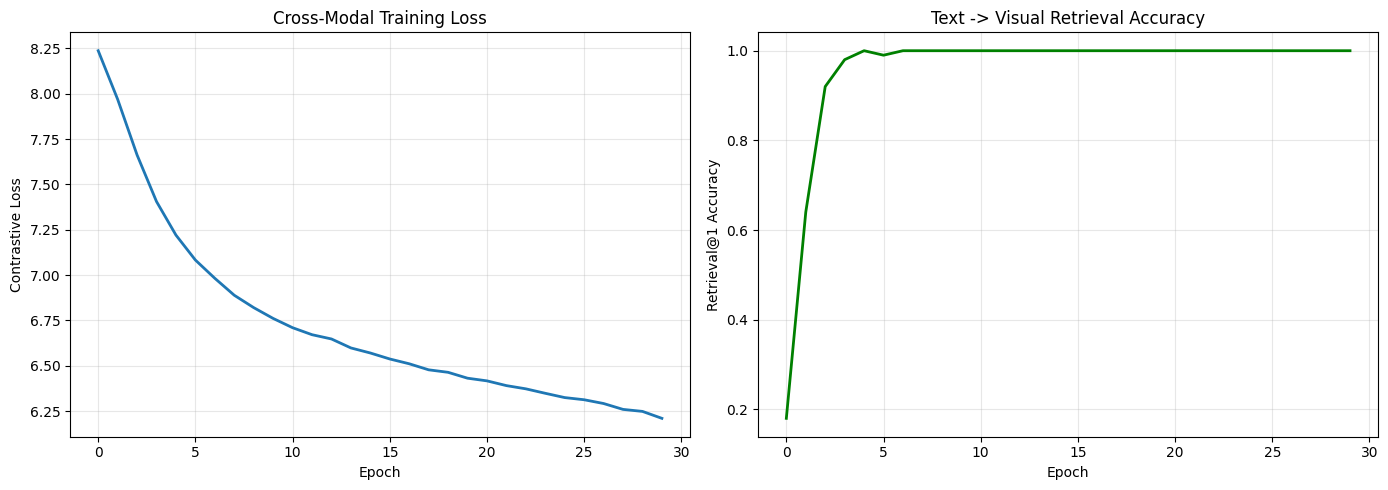

In [5]:
# Visualize cross-modal training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cm_history['loss'], linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Contrastive Loss')
axes[0].set_title('Cross-Modal Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cm_history['retrieval_acc'], linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Retrieval@1 Accuracy')
axes[1].set_title('Text -> Visual Retrieval Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Voice-First Recommendation

Voice interfaces present unique challenges:
- **Limited bandwidth**: Can present only 3-5 items (vs 20+ on screen)
- **Sequential delivery**: Items described one at a time
- **Conversational context**: Multi-turn dialogue for preference elicitation
- **Concise descriptions**: Must capture item essence in 1-2 sentences

> **⚠️ Common Pitfall:** Voice recommendation requires much higher precision than screen-based.
> Presenting 5 irrelevant items wastes 30+ seconds of the user's time, compared to a quick
> scroll on screen.

In [6]:
class VoiceRecAgent:
    """Conversational recommendation agent for voice interfaces."""
    
    def __init__(self, n_items=500, item_features=None, n_categories=10):
        self.n_items = n_items
        self.item_features = item_features if item_features is not None else np.random.randn(n_items, 32)
        self.n_categories = n_categories
        self.item_categories = np.random.randint(0, n_categories, n_items)
        self.max_voice_items = 3  # Voice can present at most 3 items
        
        # Conversation state
        self.belief = np.ones(n_items) / n_items  # Uniform prior over items
        self.conversation_history = []
    
    def reset(self):
        self.belief = np.ones(self.n_items) / self.n_items
        self.conversation_history = []
    
    def ask_question(self):
        """Select the most informative question to narrow down preferences."""
        # Find the category that best splits the current belief
        best_cat = 0
        best_info_gain = 0
        
        for cat in range(self.n_categories):
            mask = self.item_categories == cat
            p_yes = self.belief[mask].sum()
            p_no = 1 - p_yes
            if p_yes > 0 and p_no > 0:
                info_gain = -(p_yes * np.log(p_yes + 1e-8) + p_no * np.log(p_no + 1e-8))
                if info_gain > best_info_gain:
                    best_info_gain = info_gain
                    best_cat = cat
        
        return best_cat, best_info_gain
    
    def update_belief(self, category, liked):
        """Update belief based on user response."""
        mask = self.item_categories == category
        if liked:
            self.belief[mask] *= 2.0
        else:
            self.belief[mask] *= 0.3
        self.belief /= self.belief.sum()  # Normalize
        self.conversation_history.append(('category', category, liked))
    
    def recommend(self):
        """Recommend top items for voice presentation."""
        top_indices = np.argsort(self.belief)[-self.max_voice_items:][::-1]
        return top_indices, self.belief[top_indices]

# Simulate a voice recommendation conversation
agent = VoiceRecAgent(n_items=500, item_features=items['semantic'])

# Simulated user preferences
user_preferred_cats = {2, 5, 7}

print("=== Voice Recommendation Session ===")
for turn in range(4):
    cat, info_gain = agent.ask_question()
    liked = cat in user_preferred_cats
    print(f"\nTurn {turn+1}:")
    print(f"  Agent: 'Do you like category {cat}?' (info gain: {info_gain:.4f})")
    print(f"  User: {'Yes' if liked else 'No'}")
    agent.update_belief(cat, liked)
    
    recs, scores = agent.recommend()
    rec_cats = [int(agent.item_categories[i]) for i in recs]
    print(f"  Current top recs: items {recs}, categories {rec_cats}")
    print(f"  Belief entropy: {-np.sum(agent.belief * np.log(agent.belief + 1e-8)):.4f}")

=== Voice Recommendation Session ===

Turn 1:
  Agent: 'Do you like category 4?' (info gain: 0.3423)
  User: No
  Current top recs: items [499 181 165], categories [9, 2, 9]
  Belief entropy: 6.1782

Turn 2:
  Agent: 'Do you like category 9?' (info gain: 0.3562)
  User: No
  Current top recs: items [249 190 174], categories [8, 2, 6]
  Belief entropy: 6.1432

Turn 3:
  Agent: 'Do you like category 5?' (info gain: 0.3669)
  User: Yes
  Current top recs: items [134 185 349], categories [5, 5, 5]
  Belief entropy: 6.0983

Turn 4:
  Agent: 'Do you like category 5?' (info gain: 0.5195)
  User: Yes
  Current top recs: items [134 185 349], categories [5, 5, 5]
  Belief entropy: 5.9374


## 4. Spatial Recommendation (AR/VR)

In AR/VR, recommendations are placed in 3D space. We must consider:
- **User gaze direction**: What are they looking at?
- **Spatial proximity**: Nearby items are more natural to recommend
- **Visual clutter**: Don't overwhelm the user's field of view
- **Physical context**: What's around them?

Recommended items: [47, 52, 84]
Scores: ['0.084', '0.015', '0.003']


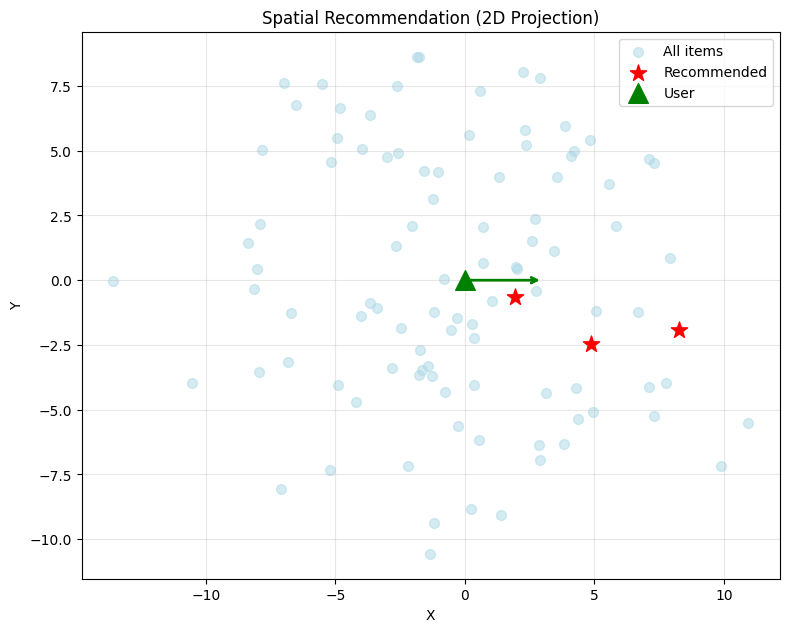

In [7]:
class SpatialRecommender:
    """Recommendation system for AR/VR spatial environments."""
    
    def __init__(self, n_items=100, spatial_dim=3):
        self.n_items = n_items
        # Items have 3D positions in the virtual space
        self.item_positions = np.random.randn(n_items, spatial_dim) * 5.0
        self.item_relevance = np.random.rand(n_items)  # Base relevance
        self.item_sizes = np.random.uniform(0.5, 2.0, n_items)  # Visual size
    
    def recommend(self, user_position, gaze_direction, fov_angle=60,
                   max_items=5, max_visual_density=0.3):
        """Recommend items considering spatial constraints."""
        # Compute direction to each item
        directions = self.item_positions - user_position
        distances = np.linalg.norm(directions, axis=1)
        directions_norm = directions / (distances[:, np.newaxis] + 1e-8)
        
        # Angle between gaze and item direction
        gaze_norm = gaze_direction / (np.linalg.norm(gaze_direction) + 1e-8)
        cos_angles = directions_norm @ gaze_norm
        angles_deg = np.degrees(np.arccos(np.clip(cos_angles, -1, 1)))
        
        # Items in field of view
        in_fov = angles_deg < fov_angle / 2
        
        # Score: relevance * proximity * gaze_alignment
        proximity_score = 1.0 / (1.0 + distances)
        gaze_score = np.clip(cos_angles, 0, 1)
        
        combined_score = self.item_relevance * proximity_score * gaze_score
        combined_score[~in_fov] = -np.inf  # Exclude items outside FOV
        
        # Select items with visual clutter constraint
        selected = []
        occupied_angles = []
        sorted_items = np.argsort(combined_score)[::-1]
        
        for item_idx in sorted_items:
            if len(selected) >= max_items:
                break
            if combined_score[item_idx] == -np.inf:
                break
            
            # Check visual clutter
            too_close = False
            for prev_item in selected:
                angle_between = np.degrees(np.arccos(np.clip(
                    np.dot(directions_norm[item_idx], directions_norm[prev_item]), -1, 1)))
                if angle_between < 10:  # Minimum 10 degree separation
                    too_close = True
                    break
            
            if not too_close:
                selected.append(item_idx)
        
        return selected, combined_score[selected] if selected else np.array([])

spatial_rec = SpatialRecommender()
user_pos = np.array([0.0, 0.0, 0.0])
gaze = np.array([1.0, 0.0, 0.0])  # Looking in +x direction

recs, scores = spatial_rec.recommend(user_pos, gaze)
print(f"Recommended items: {recs}")
print(f"Scores: {[f'{s:.3f}' for s in scores]}")

# Visualize spatial layout (2D projection)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(spatial_rec.item_positions[:, 0], spatial_rec.item_positions[:, 1],
           c='lightblue', s=50, alpha=0.5, label='All items')
if recs:
    rec_pos = spatial_rec.item_positions[recs]
    ax.scatter(rec_pos[:, 0], rec_pos[:, 1], c='red', s=150,
               marker='*', label='Recommended', zorder=5)
ax.scatter([0], [0], c='green', s=200, marker='^', label='User', zorder=5)
ax.annotate('', xy=(3, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Spatial Recommendation (2D Projection)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. IoT and Smart Home Recommendation

IoT recommendation uses sensor context to suggest actions:
- Temperature + time -> Thermostat adjustment
- Motion sensor + time -> Lighting change
- Usage pattern + calendar -> Device scheduling

> **💡 Concept:** IoT recommendations are *proactive* rather than *reactive*. The system
> should anticipate needs based on patterns, not wait for explicit requests.

In [8]:
class IoTRecommender(nn.Module):
    """Context-aware IoT recommendation model."""
    
    def __init__(self, n_devices=10, n_actions_per_device=5,
                 context_dim=8, hidden_dim=32):
        super().__init__()
        self.n_devices = n_devices
        self.n_actions = n_devices * n_actions_per_device
        
        self.context_encoder = nn.Sequential(
            nn.Linear(context_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.action_predictor = nn.Linear(hidden_dim, self.n_actions)
    
    def forward(self, context):
        hidden = self.context_encoder(context)
        action_logits = self.action_predictor(hidden)
        return action_logits

# Generate synthetic IoT data
def generate_iot_data(n_samples=3000):
    """Generate context -> action data for smart home."""
    data = []
    for _ in range(n_samples):
        hour = np.random.uniform(0, 24)
        temperature = np.random.uniform(15, 35)
        humidity = np.random.uniform(20, 90)
        motion = np.random.choice([0, 1])
        day_of_week = np.random.randint(0, 7)
        brightness = np.random.uniform(0, 1000)
        noise_level = np.random.uniform(0, 100)
        occupancy = np.random.randint(0, 5)
        
        context = [hour / 24, temperature / 35, humidity / 100, motion,
                   day_of_week / 7, brightness / 1000, noise_level / 100, occupancy / 5]
        
        # Rule-based action selection (simulated ground truth)
        if hour < 7 or hour > 23:
            action = 0  # Turn off lights
        elif temperature > 28:
            action = 10  # Turn on AC
        elif motion and brightness < 200:
            action = 5  # Turn on lights
        else:
            action = np.random.randint(0, 50)
        
        data.append((context, min(action, 49)))
    
    return data

iot_data = generate_iot_data()
split = int(0.8 * len(iot_data))

class IoTDataset(Dataset):
    def __init__(self, data):
        self.contexts = torch.tensor([d[0] for d in data], dtype=torch.float)
        self.actions = torch.tensor([d[1] for d in data], dtype=torch.long)
    def __len__(self): return len(self.contexts)
    def __getitem__(self, idx): return self.contexts[idx], self.actions[idx]

iot_train = DataLoader(IoTDataset(iot_data[:split]), batch_size=64, shuffle=True)
iot_val = DataLoader(IoTDataset(iot_data[split:]), batch_size=64)

# Train IoT recommender
iot_model = IoTRecommender()
optimizer = torch.optim.Adam(iot_model.parameters(), lr=1e-3)

iot_history = {'loss': [], 'acc': []}
for epoch in range(20):
    iot_model.train()
    total_loss = 0
    for ctx, act in iot_train:
        logits = iot_model(ctx)
        loss = F.cross_entropy(logits, act)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    iot_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for ctx, act in iot_val:
            preds = iot_model(ctx).argmax(dim=1)
            correct += (preds == act).sum().item()
            total += len(act)
    
    iot_history['loss'].append(total_loss / len(iot_train))
    iot_history['acc'].append(correct / total)

print(f"IoT Recommender - Final Accuracy: {iot_history['acc'][-1]:.4f}")

IoT Recommender - Final Accuracy: 0.5817


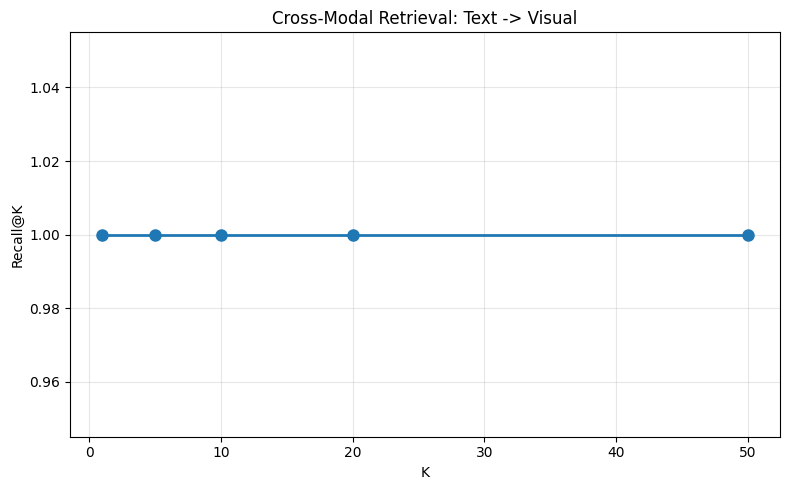

In [9]:
# Visualize cross-modal retrieval performance
cross_modal.eval()
text_feat = torch.tensor(items['text'], dtype=torch.float)
visual_feat = torch.tensor(items['visual'], dtype=torch.float)

with torch.no_grad():
    text_emb = cross_modal.encode(text_feat, 'text').numpy()
    visual_emb = cross_modal.encode(visual_feat, 'visual').numpy()

# Compute retrieval metrics at different K
ks = [1, 5, 10, 20, 50]
recall_at_k = []
for k in ks:
    sims = text_emb @ visual_emb.T
    topk_indices = np.argsort(sims, axis=1)[:, -k:]
    hits = sum(1 for i in range(len(text_emb)) if i in topk_indices[i])
    recall_at_k.append(hits / len(text_emb))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, recall_at_k, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('K')
ax.set_ylabel('Recall@K')
ax.set_title('Cross-Modal Retrieval: Text -> Visual')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🏋️ Exercise 1: Multimodal Fusion Recommender

Build a recommender that fuses text, visual, and audio features using
attention-based fusion to weight each modality dynamically.

In [10]:
# TODO: Implement attention-based multimodal fusion
class MultimodalFusionRec(nn.Module):
    def __init__(self, text_dim=64, visual_dim=128, audio_dim=32, d_model=48):
        super().__init__()
        # TODO: Modality-specific projections
        # TODO: Attention-based fusion mechanism
        # TODO: Final prediction head
        pass
    
    def forward(self, text_feat, visual_feat, audio_feat, user_query):
        # TODO: Fuse modalities with learned attention weights
        pass

print("Exercise 1: Implement multimodal fusion recommender")

Exercise 1: Implement multimodal fusion recommender


## 🏋️ Exercise 2: Conversational Preference Elicitation

Extend the VoiceRecAgent to use item features (not just categories) for
more fine-grained preference elicitation.

In [11]:
# TODO: Improve the voice agent with feature-based questions
class ImprovedVoiceAgent(VoiceRecAgent):
    def ask_feature_question(self):
        # TODO: Select the most informative feature dimension to ask about
        # (e.g., 'Do you prefer modern or classic style?')
        pass
    
    def update_belief_from_feature(self, feature_dim, value):
        # TODO: Update belief based on feature preference
        pass

print("Exercise 2: Implement improved voice preference elicitation")

Exercise 2: Implement improved voice preference elicitation


## 🏋️ Exercise 3: Gaze-Aware Recommendation

Build an AR recommendation system that tracks user gaze history
and uses it to infer implicit preferences.

In [12]:
# TODO: Implement gaze-aware AR recommendation
class GazeAwareRecommender:
    def __init__(self, n_items=100):
        # TODO: Initialize with gaze tracking buffer
        pass
    
    def record_gaze(self, gaze_target_item, duration_ms):
        # TODO: Record gaze event and update item interest scores
        pass
    
    def recommend(self):
        # TODO: Use gaze history to recommend items
        pass

print("Exercise 3: Implement gaze-aware AR recommendation")

Exercise 3: Implement gaze-aware AR recommendation


## Summary

In this notebook, we explored emerging modalities for recommendation:

1. **Cross-modal recommendation**: Contrastive learning for shared embedding spaces
2. **Voice-first interfaces**: Conversational preference elicitation under bandwidth constraints
3. **Spatial (AR/VR)**: Gaze-aware, clutter-avoiding 3D recommendations
4. **IoT/Smart Home**: Context-aware proactive recommendations from sensor data
5. **Multimodal fusion**: Combining information from multiple modalities

### Key Takeaways

- Each modality imposes unique constraints on recommendation design
- Voice interfaces demand higher precision due to limited bandwidth
- Spatial context (gaze, proximity) is a powerful implicit feedback signal
- Cross-modal learning enables search and recommendation across modalities
- IoT recommendation is proactive, anticipating needs before explicit requests